# 鸢尾花应用

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

## 加载数据

In [2]:
# ====== 加载数据 ======
iris = load_iris()
X, y = iris.data, iris.target
target_names = iris.target_names
feature_names = iris.feature_names

print(f"原始数据维度: {X.shape}") # (150,4)

原始数据维度: (150, 4)


## 标准化

In [3]:
# ====== 标准化 ======
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 分析特征相关性

In [4]:
# ====== 分析特征相关性 ======
corr_matrix = np.corrcoef(X_scaled, rowvar = False)
print("\n特征相关系数矩阵:")
print(np.round(corr_matrix, 3))


特征相关系数矩阵:
[[ 1.    -0.118  0.872  0.818]
 [-0.118  1.    -0.428 -0.366]
 [ 0.872 -0.428  1.     0.963]
 [ 0.818 -0.366  0.963  1.   ]]


## PCA 降维

In [5]:
# ====== PCA 降维 ======
pca = PCA()
pca.fit(X_scaled)

print("\n各主成分特征值（方差）:", np.round(pca.explained_variance_, 4))
print("各主成分方差解释率:    ", np.round(pca.explained_variance_ratio_, 4))
print("累计方差解释率:        ", np.round(np.cumsum(pca.explained_variance_ratio_),4))

# 输出主成分载荷（特征向量），理解每个主成分的含义
print("\n主成分载荷矩阵（每列是一个主成分方向）:")
loadings = pca.components_.T
for i,fname in enumerate(feature_names):
  print(f"  {fname:30s}: PC1={loadings[i,0]:+.3f} PC2={loadings[i,1]:+.3f}")

# 降到 2 维
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)


各主成分特征值（方差）: [2.9381 0.9202 0.1477 0.0209]
各主成分方差解释率:     [0.7296 0.2285 0.0367 0.0052]
累计方差解释率:         [0.7296 0.9581 0.9948 1.    ]

主成分载荷矩阵（每列是一个主成分方向）:
  sepal length (cm)             : PC1=+0.521 PC2=+0.377
  sepal width (cm)              : PC1=-0.269 PC2=+0.923
  petal length (cm)             : PC1=+0.580 PC2=+0.024
  petal width (cm)              : PC1=+0.565 PC2=+0.067


- PC1（解释 72.96% 方差）：
  1. petal length 花瓣长度(+0.58)
  2. petal width 花瓣宽度(+0.57)
  3. sepal length 花萼长度(+0.52) 
   
   三者都有较大正载荷，PC1 代表花的整体大小，数值越大，花越大
- PC2（解释 22.85% 方差）：
    
    几乎只由 sepal width 花萼宽主导（+0.923），其他特征贡献很小，可以理解为 PC2 专门代表 花萼宽度
- 仅用 2 个主成分就捕获了 95.8% 的信息，同时从可视化图中能清晰看到三个类别的分布

## 可视化

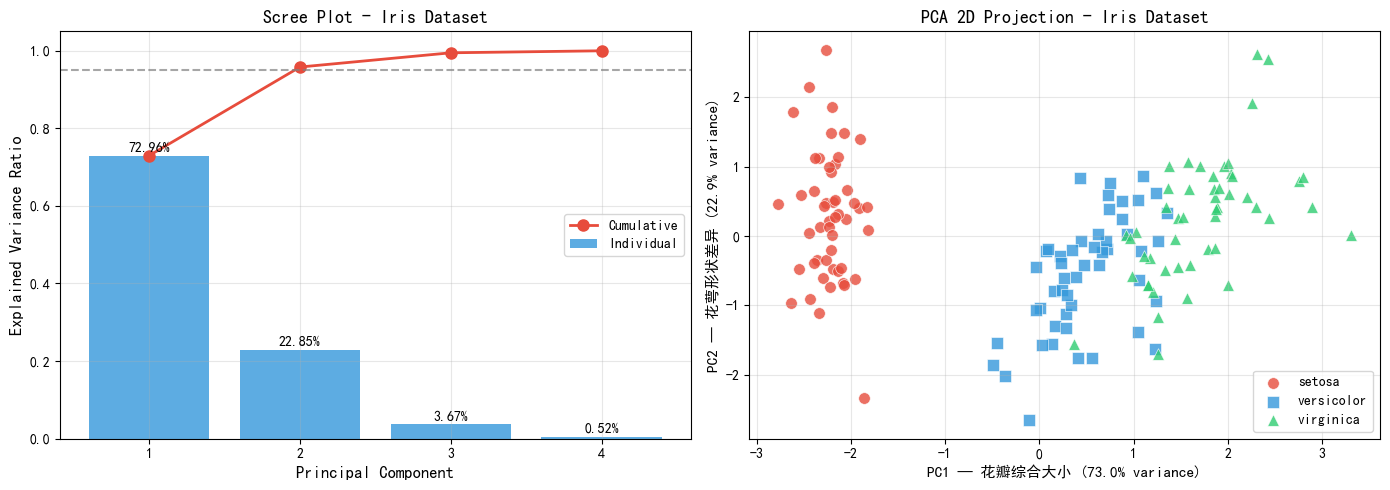

In [6]:
# ====== 可视化 ======
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 左图: 碎石图 scree ---
components = range(1, 5)
axes[0].bar(components, pca.explained_variance_ratio_,
            color='#3498db', alpha=0.8, label='Individual')
axes[0].plot(components, np.cumsum(pca.explained_variance_ratio_),
             'o-', color='#e74c3c', linewidth=2, markersize=8, label='Cumulative')
axes[0].axhline(y=0.95, color='gray', linestyle='--', alpha=0.7)
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('Scree Plot - Iris Dataset', fontsize=13)
axes[0].set_xticks(components)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 标注每个柱子的值
for i, v in enumerate(pca.explained_variance_ratio_):
    axes[0].text(i + 1, v + 0.01, f'{v:.2%}', ha='center', fontsize=10)

# --- 右图：2D 投影散点图 ---
colors = ['#e74c3c', '#3498db', '#2ecc71']
markers = ['o', 's', '^']
for i, (color, marker, name) in enumerate(zip(colors, markers, target_names)):
    mask = y == i
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=color, marker=marker, label=name,
                    alpha=0.8, edgecolors='w', s=70, linewidths=0.5)

axes[1].set_xlabel(
    f'PC1 — 花瓣综合大小 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)',
    fontsize=11)
axes[1].set_ylabel(
    f'PC2 — 花萼形状差异 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)',
    fontsize=11)
axes[1].set_title('PCA 2D Projection - Iris Dataset', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('iris_pca.png', dpi=150, bbox_inches='tight')
plt.show()